In [1]:
import SimpleITK as sitk
from downloaddata import fetch_data as fdata
%matplotlib widget
%matplotlib notebook
import gui
import registration_gui as rgui
import pydicom
import numpy as np
import os
from skimage import io
from scipy.ndimage import affine_transform
%matplotlib inline
import matplotlib.pyplot as plt

import k3d
from k3d.colormaps import matplotlib_color_maps
OUTPUT_DIR = "output"


In [ ]:
import pydicom
lstFilesDCM = []  # create an empty list
for dirName, subdirList, fileList in os.walk(path_subfolder2):
    for filename in fileList:
        if ".dcm" in filename.lower():  # check whether the file's DICOM
            lstFilesDCM.append(os.path.join(dirName,filename))
            #print(lstFilesDCM)
            # Get Metadata from dicom
            RefDs = pydicom.read_file(lstFilesDCM[0])
            #RefDs.decompress('gdcm')
elem = RefDs[0x0020, 0x0037]
print(elem)


In [2]:
path="../../DATA/registration_test/FB_100030____FB,2817673489/study_0c1e55cc/"
path_subfolder1=path+"MR7_bb3b1a0b"#"MR3_33a7c6a2"#"MR4_c61744e9"#"MR3_33a7c6a2"
path_subfolder2=path+"MR5_2e0c276a"
path_subfolder3=path+"MR3_33a7c6a2"

In [3]:
# read 2 series (sagittal / coronal / axial)
reader1 = sitk.ImageSeriesReader()
dicom_names1 = reader1.GetGDCMSeriesFileNames(path_subfolder1)
reader1.SetFileNames(dicom_names1)
sag_image = reader1.Execute()
sag_image = sitk.Cast(sag_image, sitk.sitkFloat32)

reader2 = sitk.ImageSeriesReader()
dicom_names2 = reader2.GetGDCMSeriesFileNames(path_subfolder2)
reader2.SetFileNames(dicom_names2)
cor_image = reader2.Execute()
cor_image = sitk.Cast(cor_image, sitk.sitkFloat32)

reader3 = sitk.ImageSeriesReader()
dicom_names3 = reader3.GetGDCMSeriesFileNames(path_subfolder3)
reader3.SetFileNames(dicom_names3)
ax_image = reader3.Execute()
ax_image = sitk.Cast(ax_image, sitk.sitkFloat32)

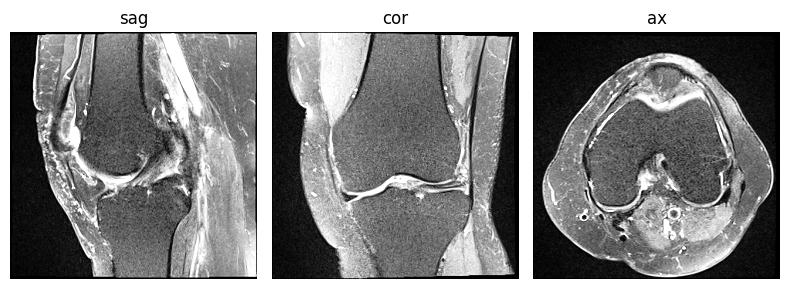

In [4]:
# quick series visualization
mr_window_level = [1036, 520]

gui.MultiImageDisplay(
    image_list=[sag_image, cor_image, ax_image],
    title_list=["sag", "cor", "ax"],
    figure_size=(8, 4),
    window_level_list=[mr_window_level, mr_window_level, mr_window_level],
);

In [ ]:
#registration CORONAL ON SAGITTAL
elastixImageFilterCOR = sitk.ElastixImageFilter()
elastixImageFilterCOR.SetFixedImage(sag_image)
elastixImageFilterCOR.SetMovingImage(cor_image)
elastixImageFilterCOR.SetParameterMap(sitk.GetDefaultParameterMap("rigid"))
elastixImageFilterCOR.Execute()
transformParameterMapCOR = elastixImageFilterCOR.GetTransformParameterMap()

#sitk.WriteImage(elastixImageFilter.GetResultImage())

In [ ]:
resultCOR = elastixImageFilterCOR.GetResultImage()

In [ ]:
#registration AXIAL ON SAGITTAL

elastixImageFilterAX = sitk.ElastixImageFilter()
elastixImageFilterAX.SetFixedImage(sag_image)
elastixImageFilterAX.SetMovingImage(ax_image)
elastixImageFilterAX.SetParameterMap(sitk.GetDefaultParameterMap("rigid"))
elastixImageFilterAX.Execute()
transformParameterMapAX = elastixImageFilterAX.GetTransformParameterMap()


In [ ]:
resultAX = elastixImageFilterAX.GetResultImage()

In [ ]:
print('origin: ' + str(sag_image.GetOrigin()))
print('size: ' + str(sag_image.GetSize()))
print('spacing: ' + str(sag_image.GetSpacing()))
print('direction: ' + str(sag_image.GetDirection()))

In [ ]:
print('origin: ' + str(cor_image.GetOrigin()))
print('size: ' + str(cor_image.GetSize()))
print('spacing: ' + str(cor_image.GetSpacing()))
print('direction: ' + str(cor_image.GetDirection()))

In [ ]:
print('origin: ' + str(ax_image.GetOrigin()))
print('size: ' + str(ax_image.GetSize()))
print('spacing: ' + str(ax_image.GetSpacing()))
print('direction: ' + str(ax_image.GetDirection()))

In [ ]:
print('origin: ' + str(resultCOR.GetOrigin()))
print('size: ' + str(resultCOR.GetSize()))
print('spacing: ' + str(resultCOR.GetSpacing()))
print('direction: ' + str(resultCOR.GetDirection()))

In [ ]:
print('origin: ' + str(resultAX.GetOrigin()))
print('size: ' + str(resultAX.GetSize()))
print('spacing: ' + str(resultAX.GetSpacing()))
print('direction: ' + str(resultAX.GetDirection()))

In [ ]:
gui.MultiImageDisplay(
    image_list=[sag_image, resultCOR, resultAX],
    title_list=["sag", "cor reg", "ax reg"],
    figure_size=(8, 4),
    window_level_list=[mr_window_level, mr_window_level, mr_window_level],
);

In [ ]:
# Extract the matrix from the TransformParameterMapType object
matrixCOR = np.array(transformParameterMapCOR[0]['TransformParameters'], dtype=float)
matrixAX = np.array(transformParameterMapAX[0]['TransformParameters'], dtype=float)

print(matrixCOR)
print(matrixAX)


In [ ]:
vol1 = sitk.GetArrayFromImage(sag_image)
vol2 = sitk.GetArrayFromImage(resultCOR)
vol3 = sitk.GetArrayFromImage(resultAX)

vol4 = sitk.GetArrayFromImage(cor_image)
vol5 = sitk.GetArrayFromImage(ax_image)

In [ ]:
plt_vol1= k3d.volume(vol1.astype(np.float32), alpha_coef=75,color_map=matplotlib_color_maps.Turbo)
plt_vol2= k3d.volume(vol2.astype(np.float32), alpha_coef=75,color_map=matplotlib_color_maps.Turbo)
plt_vol3= k3d.volume(vol3.astype(np.float32), alpha_coef=75,color_map=matplotlib_color_maps.Turbo)
plt_vol4= k3d.volume(vol4.astype(np.float32), alpha_coef=75,color_map=matplotlib_color_maps.Turbo)
plt_vol5= k3d.volume(vol5.astype(np.float32), alpha_coef=75,color_map=matplotlib_color_maps.Turbo)
plot = k3d.plot()
plot += plt_vol1
plot += plt_vol2
plot += plt_vol3
plot += plt_vol4
plot += plt_vol5

plot.display()

In [ ]:
spacing1 = fixed_image.GetSpacing()
spacing2 = moving_image.GetSpacing()
origin1= fixed_image.GetOrigin()
origin2=moving_image.GetOrigin()
shape = np.array([vol1.shape, vol2.shape]).max(axis=0)
print(shape)

In [ ]:
#get position in each axes
ArrayPositionX_1=np.arange(0,int(ndf.shape[1]) )* float(rx1) #Width
ArrayPositionX_2=np.arange(0,int(nda.shape[0]) )* float(ry2)

ArrayPositionX=np.append(ArrayPositionX_1, ArrayPositionX_2)
print(ArrayPositionX.shape)

In [ ]:
# Define the arrays of x, y, and z coordinates for each volume
x1, y1, z1 = np.meshgrid(np.arange(vol1.shape[0]) * spacing1[0] + origin1[0],
                         np.arange(vol1.shape[1]) * spacing1[1] + origin1[1],
                         np.arange(vol1.shape[2]) * spacing1[2] + origin1[2],
                         indexing='ij')

x2, y2, z2 = np.meshgrid(np.arange(vol2.shape[0]) * spacing2[0] + origin2[0],
                         np.arange(vol2.shape[1]) * spacing2[1] + origin2[1],
                         np.arange(vol2.shape[2]) * spacing2[2] + origin2[2],
                         indexing='ij')

In [ ]:
# get volumes as np.array() 

nda = sitk.GetArrayFromImage(moving_resampled)
print("Image size: " + str(moving_resampled.GetSize()))
print("Numpy array size: " + str(nda.shape))

In [ ]:
ndf = sitk.GetArrayFromImage(fixed_image)
print(ndf.shape)

In [ ]:
ConstPixelDims = (float(fixed_image.GetSpacing()[0]), float(fixed_image.GetSpacing()[0]), float(fixed_image.GetSpacing()[0]))
print(ConstPixelDims)

In [ ]:
plotndf = plt.imshow(ndf[int(ndf.shape[0]/2),:,:])

In [ ]:
plotndf = plt.imshow(nda[int(nda.shape[0]/2),:,:])

In [ ]:
moving=sitk.GetArrayFromImage(moving_image)
plotndf = plt.imshow(moving[int(nda.shape[0]/2),:,:])

In [ ]:
# k3d points representation
#plt_points_fixed = k3d.points(fixed_image,color=0x528881,point_size=0.2)
#plt_points_moved = k3d.points(nda,color=0x1e1e1e,point_size=0.2)
#plot = k3d.plot()
#plot += plt_points_fixed
#plot += plt_points_moved
#plot.display()

# k3d volume visualization / superpose 2 volumes after registration
plt_vol_fixed= k3d.volume(ndf.astype(np.float32), alpha_coef=75,color_map=matplotlib_color_maps.Turbo)
plt_vol_moved= k3d.volume(nda.astype(np.float32), alpha_coef=75,color_map=matplotlib_color_maps.Turbo)
plot = k3d.plot()
plot += plt_vol_fixed
plot += plt_vol_moved
plot.display()


In [ ]:
#nda registration / ndf fixed 
print(ndf.shape[1], float(fixed_image.GetSpacing()[0]))
print(nda.shape[0], float(moving_resampled.GetSpacing()[2]))

# define voxel size in different axes
rx1=fixed_image.GetSpacing()[0]
rx2=moving_resampled.GetSpacing()[0]

ry1=fixed_image.GetSpacing()[2]
ry2=moving_resampled.GetSpacing()[2]

rz=fixed_image.GetSpacing()[1]

print(rx1, rx2, ry1, ry2, rz)

In [ ]:
#get position in each axes
ArrayPositionX_1=np.arange(0,int(ndf.shape[1]) )* float(rx1) #Width
ArrayPositionX_2=np.arange(0,int(nda.shape[0]) )* float(ry2)

ArrayPositionX=np.append(ArrayPositionX_1, ArrayPositionX_2)
print(ArrayPositionX.shape)

In [ ]:
ArrayPositionY_1=np.arange(0,int(ndf.shape[0]) )* float(ry1) 
ArrayPositionY_2=np.arange(0,int(nda.shape[1]) )* float(rx2)

ArrayPositionY=np.append(ArrayPositionY_2, ArrayPositionY_1)
print(ArrayPositionY.shape)

In [ ]:
ArrayPositionX_s=np.unique(ArrayPositionX[np.argsort(ArrayPositionX)])
ArrayPositionY_s=np.unique(ArrayPositionY[np.argsort(ArrayPositionX)])
print(len(ArrayPositionX_s))
print(len(ArrayPositionY_s))
#print(ArrayPositionY_s)

In [ ]:
ArrayPositionZ=np.arange(0,ndf.shape[2] )* float(rz)
#print(ArrayPositionZ)

In [ ]:
# new volume (Z, Y, X)
Array=np.zeros((ndf.shape[2], len(ArrayPositionY_s), len(ArrayPositionX_s)), dtype=np.float32)#*np.nan
print(Array.shape)

In [ ]:
# get all values from vol1 (fixed) and put it in new volume 
for z in range(0, ndf.shape[1]):
    for y in range(0,ndf.shape[0]):
        for x in range(0, ndf.shape[2]):
            val_ndf=ndf[y,z,x]
            posRz=z*rz
            posRx=x*rx1
            posRy=y*ry1
            indexX= np.where(ArrayPositionX_s==posRx)[0][0]
            indexY= np.where(ArrayPositionY_s==posRy)[0][0]
            indexZ= np.where(ArrayPositionZ==posRz)[0][0]
            #print(posRz, posRx, posRy, indexZ, indexX, indexY, ArrayPositionX_s[indexX], ArrayPositionY_s[indexY])
            Array[indexZ,indexY,indexX]=val_ndf

In [ ]:
plt_vol_array= k3d.volume(Array.astype(np.float32), alpha_coef=100,color_map=matplotlib_color_maps.Turbo)
plot = k3d.plot()
plot += plt_vol_array
plot.display()

In [ ]:
# get all values from vol2 (after registration) and put it in new volume 
for z in range(0, nda.shape[1]):
    for y in range(nda.shape[2]-1,-1,-1): #y c'est -x de nda
        for x in range(nda.shape[0]-1,-1,-1):# x c'est -y de nda
            val_nda=nda[x,z,y]
            posRz=z*rz
            posRx=(nda.shape[0]-1-x)*ry2
            posRy=(nda.shape[2]-1-y)*rx1
            indexX= np.where(ArrayPositionX_s==posRx)[0][0]
            indexY= np.where(ArrayPositionY_s==posRy)[0][0]
            indexZ= np.where(ArrayPositionZ==posRz)[0][0]
            #print(posRz, posRx, posRy, indexZ, indexX, indexY, ArrayPositionX_s[indexX], ArrayPositionY_s[indexY])
            Array[indexZ,indexX,indexY]=val_nda

In [ ]:
plt_vol_array= k3d.volume(Array.astype(np.float32), alpha_coef=100,color_map=matplotlib_color_maps.Turbo)
plot = k3d.plot()
plot += plt_vol_array
plot.display()

In [ ]:
io.imsave("VolCombined.tif", Array)